In [1]:
%pip install -r utils/requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [ ]:


import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
from pathlib import Path

# Set up paths - Data is in utils/Data/Clean/
waldo_path = '/workspaces/wheres-wally/utils/Data/Clean/ClearedWaldos/'
heads_path = '/workspaces/wheres-wally/utils/Data/Clean/OnlyWaldoHeads/'

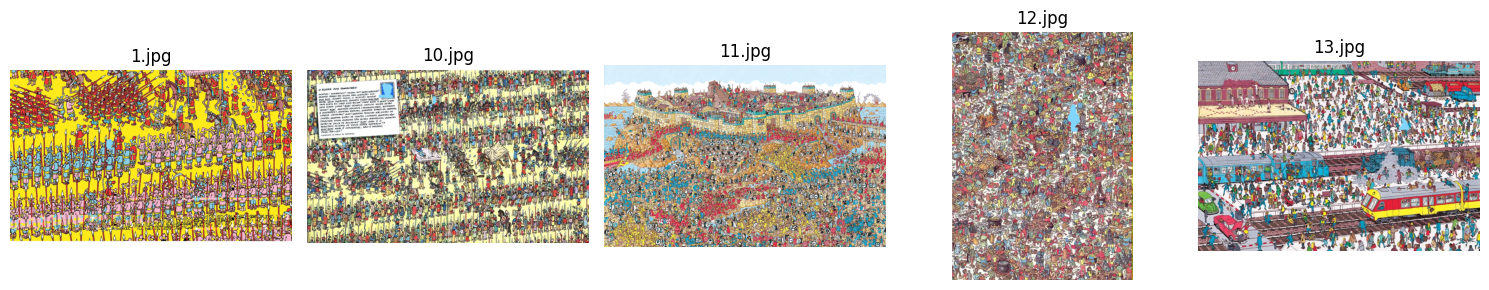

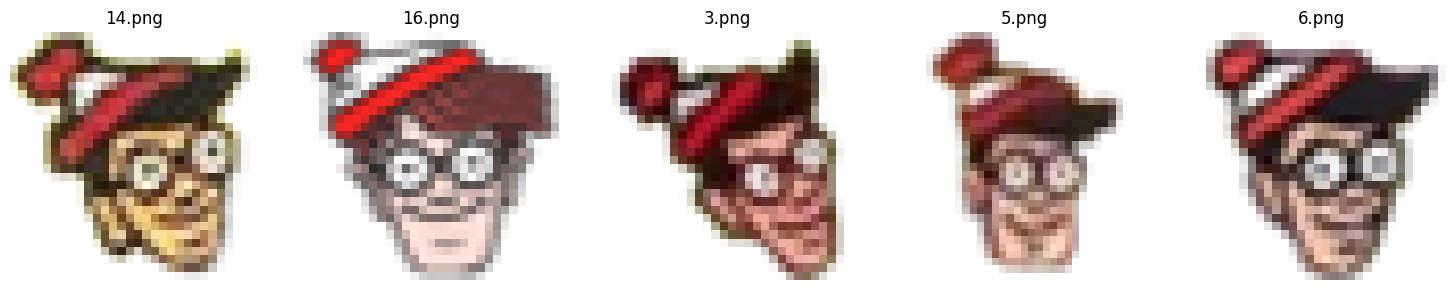

In [3]:
# Display examples of Only Wally
waldo_files = sorted([f for f in os.listdir(waldo_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(waldo_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(waldo_files[:num_samples]):
    img = mpimg.imread(os.path.join(waldo_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

# Display examples of Only Wally Heads
heads_files = sorted([f for f in os.listdir(heads_path) if f.endswith(('.jpg', '.png'))])
num_samples = min(5, len(heads_files))

fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

for idx, file in enumerate(heads_files[:num_samples]):
    img = mpimg.imread(os.path.join(heads_path, file))
    if num_samples == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [4]:
import os
import sys

os.chdir('/workspaces/wheres-wally/utils')
sys.path.insert(0, '/workspaces/wheres-wally/utils')

try:
    from DataAugmentation import generating_waldos
    generating_waldos(use_background=True, variations_per_combo=2, max_images=100, 
                      max_heads=3, max_backgrounds=15, sample_ratio=1)
except Exception as e:
    print(f"Error type: {type(e).__name__}")
    print(f"Error message: {e}")
    import traceback
    traceback.print_exc()

Data path: /workspaces/wheres-wally/utils/Data
Found 6 head images, 33 background images
Using 3 heads × 15 backgrounds × 2 variations
Will generate up to 90 total images


Progress: 50/90 images generated (55%)

Generated 90 training images
  - 90 Waldo images saved to /workspaces/wheres-wally/utils/Data/Waldo
  - 90 NotWaldo images saved to /workspaces/wheres-wally/utils/Data/NotWaldo


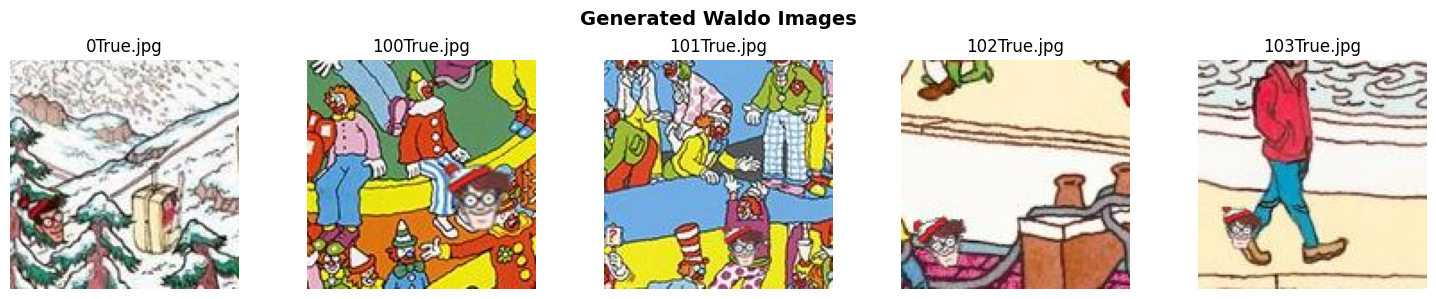

In [5]:
# List the generated Waldo images from the DataAugmentation output
waldo_generated_files = sorted([f for f in os.listdir('/workspaces/wheres-wally/utils/Data/Waldo') if f.endswith('.jpg')])[:5]

# Display 5 images from the generated Waldo dataset
fig, axes = plt.subplots(1, len(waldo_generated_files), figsize=(15, 3))
fig.suptitle('Generated Waldo Images', fontsize=14, fontweight='bold')

for idx, file in enumerate(waldo_generated_files):
    img = mpimg.imread(os.path.join('/workspaces/wheres-wally/utils/Data/Waldo', file))
    if len(waldo_generated_files) == 1:
        axes.imshow(img)
        axes.set_title(file)
        axes.axis('off')
    else:
        axes[idx].imshow(img)
        axes[idx].set_title(file)
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

In [6]:
import os
import sys
from pathlib import Path
import gc

# Define and add utils directory to Python path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

from TrainModel import train_waldo_model

# Clear any existing memory
gc.collect()

# Create simple output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'waldo_model.weights.h5'  # Fixed: must end in .weights.h5
data_dir = Path(utils_path) / 'Data'

# Train model from scratch with reduced epochs to prevent crashes
print("Training Waldo detection model from scratch...")
model, X_test, Y_test, score = train_waldo_model(
    data_path=str(data_dir),
    epochs=20,  # Reduced from 15 to 5 to prevent kernel crash
    test_size=0.10,
    save_path=str(save_path)
)
print(f"✓ Model saved to: {save_path}")

2026-01-29 12:57:02.764747: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-29 12:57:02.770533: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 12:57:02.773808: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-29 12:57:02.783726: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-29 12:57:02.798385: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

Training Waldo detection model from scratch...
Loading Waldo images (label=1)...
Loading NotWaldo images (label=0)...

Total images: 792
Waldo images: 396.0, NotWaldo images: 396.0
Data loading time: 1.54 seconds

X_train shape: (712, 128, 128, 3)
X_test shape: (80, 128, 128, 3)

Training model...
Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 957ms/step - accuracy: 0.5000 - loss: 0.6954 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 40s 884ms/step - accuracy: 0.4635 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 45s 978ms/step - accuracy: 0.5000 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 78s 894ms/step - accuracy: 0.4635 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 44s 956ms/step - accuracy: 0.4775 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 79s 901ms/step - a

In [ ]:
import os
import sys
from pathlib import Path
import gc

# Define and add utils directory to Python path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

from Train import locate

# Clear any existing memory
gc.collect()

# Create simple output directory
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)

save_path = output_dir / 'waldo_model.weights.h5'  # Fixed: must end in .weights.h5
data_dir = Path(utils_path) / 'Data'

# Train model from scratch with reduced epochs to prevent crashes
print("Training Waldo detection model from scratch...")
model, X_test, Y_test, score = train_waldo_model(
    data_path=str(data_dir),
    epochs=20,  # Reduced from 15 to 5 to prevent kernel crash
    test_size=0.10,
    save_path=str(save_path)
)
print(f"✓ Model saved to: {save_path}")

In [1]:
import os
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Add utils to path
utils_path = '/workspaces/wheres-wally/utils'
if utils_path not in sys.path:
    sys.path.insert(0, utils_path)

from TrainPyTorch import train_waldo_pytorch

# Configuration
data_dir = Path(utils_path) / 'Data'
output_dir = Path('output')
output_dir.mkdir(exist_ok=True)
save_path = output_dir / 'localize4_pytorch.pth'

# Train model
print("Training Waldo detection model with PyTorch...")
model, X_test, Y_test, metrics = train_waldo_pytorch(
    data_path=str(data_dir),
    epochs=15,
    test_size=0.10,
    save_path=str(save_path),
    img_size=64,  # Match Train.py
    batch_size=32,
    learning_rate=0.001
)

print(f"✓ Training complete!")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(metrics['train_losses'], label='Train Loss')
ax1.plot(metrics['val_losses'], label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(metrics['val_accuracies'], label='Val Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"\nFinal Test Accuracy: {metrics['test_accuracy']:.4f}")

ModuleNotFoundError: No module named 'torch'

In [ ]:
import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt

def locate(image_path, model, threshold=0.99, stride=8, window_size=64):
    """
    Locate Waldo in a full scene image using sliding window approach.
    Mimics the Train.py locate() function behavior.
    """
    
    # Load image
    data = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    h, w = data.shape[:2]
    
    # Create heatmap using sliding window
    heatmap_h = (h - window_size) // stride + 1
    heatmap_w = (w - window_size) // stride + 1
    heatmap = np.zeros((heatmap_h, heatmap_w))
    
    model.eval()
    device = next(model.parameters()).device
    
    print(f"Scanning {w}x{h} image with {heatmap_h * heatmap_w} windows...")
    
    with torch.no_grad():
        for y_idx, y in enumerate(range(0, h - window_size + 1, stride)):
            for x_idx, x in enumerate(range(0, w - window_size + 1, stride)):
                # Extract and prepare window
                window = data[y:y+window_size, x:x+window_size]
                window_tensor = torch.from_numpy(window).permute(2, 0, 1).float() / 255.0
                window_tensor = window_tensor.unsqueeze(0).to(device)
                
                # Get prediction (probability of Waldo)
                output = model(window_tensor)
                prob = torch.softmax(output, dim=1)[0, 1].item()
                heatmap[y_idx, x_idx] = prob
    
    # Visualize results
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(data)
    axes[0].set_title("Original Image")
    axes[0].axis('off')
    
    im = axes[1].imshow(heatmap, cmap='hot')
    axes[1].set_title("Heatmap")
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])
    
    axes[2].imshow(heatmap > threshold, cmap="gray")
    axes[2].set_title(f"Detections (threshold={threshold})")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Draw bounding boxes on detections (Red boxes like Train.py)
    yy, xx = np.where(heatmap > threshold)
    annotated = data.copy()
    
    for y_idx, x_idx in zip(yy, xx):
        y = y_idx * stride
        x = x_idx * stride
        cv2.rectangle(annotated, (x, y), (x + window_size, y + window_size), (255, 0, 0), 5)
    
    print(f"Found {len(yy)} potential Waldo locations")
    
    return annotated, heatmap

# Test localization on a full scene image
scene_image_path = '/workspaces/wheres-wally/utils/Data/Raw/Train/1.jpg'

if os.path.exists(scene_image_path):
    print(f"\nLocating Waldo in {scene_image_path}...")
    annotated, heatmap = locate(scene_image_path, model, threshold=0.99, stride=8, window_size=64)
    
    plt.figure(figsize=(15, 10))
    plt.imshow(annotated)
    plt.title("Detected Waldo Locations (Red Boxes)")
    plt.axis('off')
    plt.show()
else:
    print(f"Scene image not found at: {scene_image_path}")
    print("Please place a full 'Where's Waldo' scene image to test localization.")
    print("You can also call: locate('path/to/your/image.jpg', model)")